In [9]:
import os
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

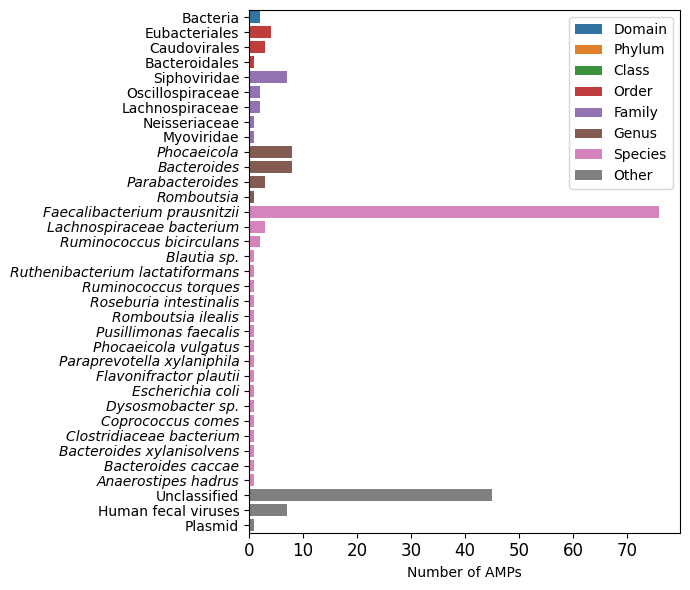

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv("./193_amps_trans_norm_format_filt.tsv", sep="\t")

# DCustom rank order
rank_order = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species", "Other"]

data["rank"] = pd.Categorical(data["rank"], categories=rank_order, ordered=True)

data = data.sort_values(by=["rank", "count"], ascending=[True, False])

# To mantain order
data["megan6.classification"] = pd.Categorical(data["megan6.classification"], categories=data["megan6.classification"].unique(), ordered=True)

# Figure size
plt.figure(figsize=(7, 6))

# Create bar plot with ordered classification
barplots = sns.barplot(data=data, y="megan6.classification", x="count", hue="rank", dodge=False)

# Labels
plt.xlabel("Number of AMPs")
plt.ylabel("")
plt.legend(title="")
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)

# Get the current y-tick labels
ax = plt.gca()
yticks = ax.get_yticklabels()

# Apply italics to genus and species labels
for label in yticks:
    taxon = label.get_text()
    taxon_rank = data.loc[data["megan6.classification"] == taxon, "rank"].values[0]  # Get rank

    if taxon_rank in ["Genus", "Species"]:  # Italicize only these ranks
        label.set_fontstyle("italic")

plt.tight_layout()
plt.savefig("./taxa_sum_filt.svg")
plt.savefig("./taxa_sum_filt.png")
plt.show()
